In [ ]:
!pip install kaggle evaluate wordcloud transformers

import os
from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download waalbannyantudre/hate-speech-detection-curated-dataset
!unzip hate-speech-detection-curated-dataset.zip

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.6 MB/s eta 0:00:00


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/waalbannyantudre/hate-speech-detection-curated-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 98% 112M/114M [00:00<00:00, 265MB/s] 
100% 114M/114M [00:00<00:00, 230MB/s]
Archive:  hate-speech-detection-curated-dataset.zip
  inflating: HateSpeechDataset.csv   
  inflating: HateSpeechDatasetBalanced.csv  


In [ ]:
# Cell 3: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
from tqdm import tqdm
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

%matplotlib inline


In [ ]:
data_full = pd.read_csv('HateSpeechDatasetBalanced.csv')
print(f'Rows: {data_full.shape[0]},  columns: {data_full.shape[1]}')
print(data_full.sample(3))

Rows: 726119,  columns: 2
                                                  Content  Label
213379  thanks for unblocking me thanks khoikhoi for u...      0
283042  sabra and spatial a genocide hi jay jg uno vot...      0
175001                      ian better is a fucking penis      1


In [ ]:
df1 = data_full[data_full['Label'] == 0].sample(4000, random_state=42)
df2 = data_full[data_full['Label'] == 1].sample(4000, random_state=42)
data = pd.concat([df1, df2], ignore_index=True)

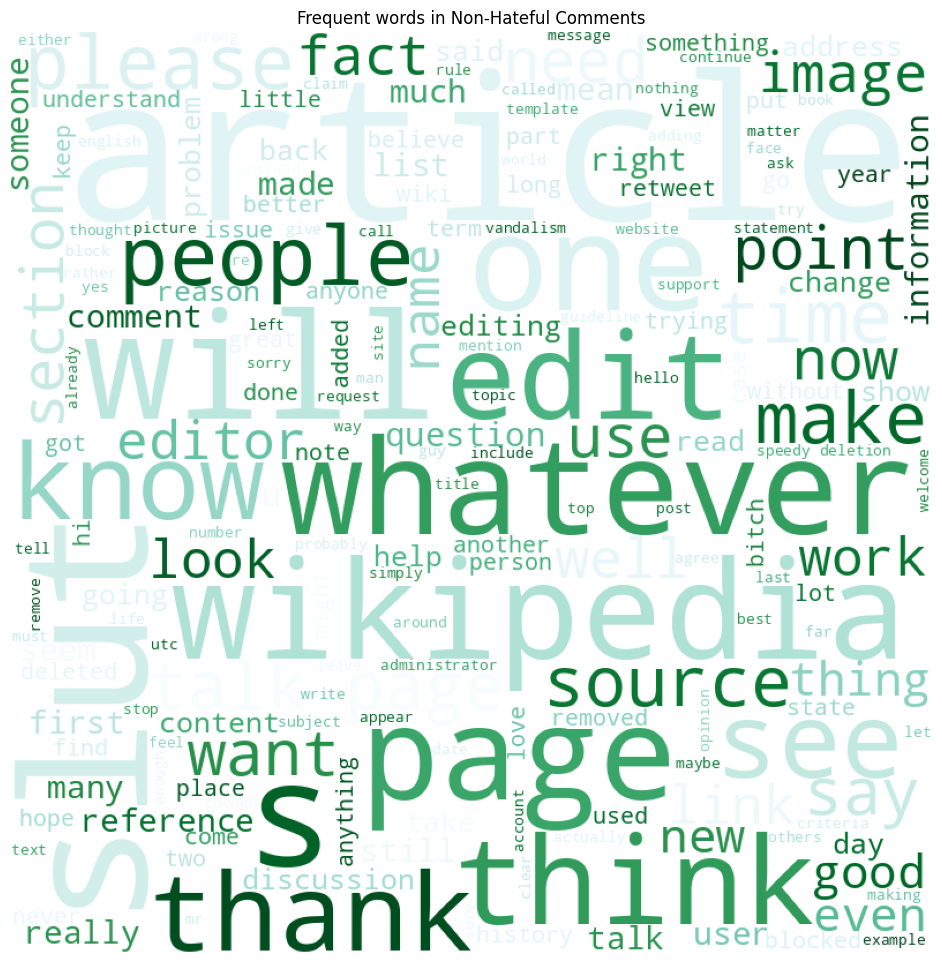

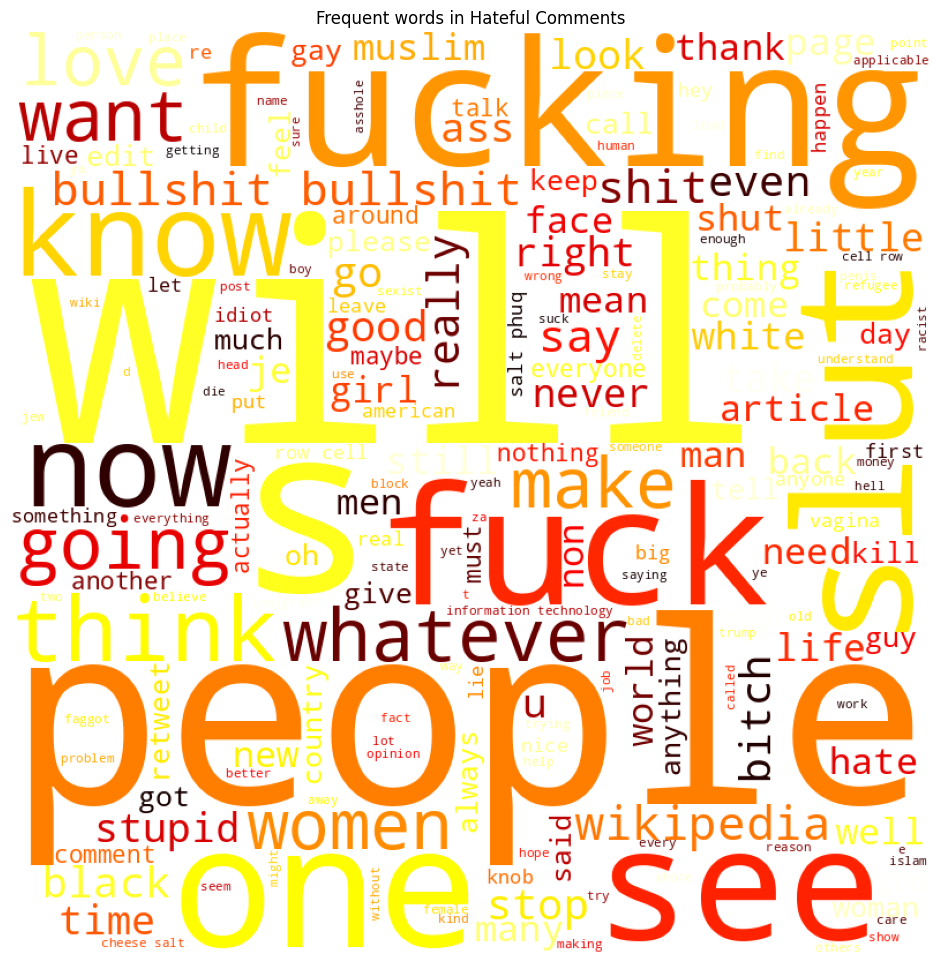

In [ ]:
def create_wordcloud(df, title):
    combined_text = ' '.join(df['Content'])
    wordcloud_img = WordCloud(width=800, height=800, background_color='white',
                              colormap='BuGn' if 'Non-Hateful' in title else 'hot_r',
                              min_font_size=10).generate(combined_text)
    plt.figure(figsize=(10,10))
    plt.imshow(wordcloud_img)
    plt.axis('off')
    plt.title(title)
    plt.tight_layout(pad=2)
    plt.show()

create_wordcloud(df1, 'Frequent words in Non-Hateful Comments')
create_wordcloud(df2, 'Frequent words in Hateful Comments')

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stopwords_l = set(stopwords.words('english'))
punctuation = re.compile("[" + re.escape(string.punctuation) + "]")
lemmatizer = WordNetLemmatizer()
stemmer = SnowballStemmer('english')

def text_cleaning(text, mode="stemming"):
    text_clean = re.sub(punctuation, '', text.lower())
    tokens = word_tokenize(text_clean)
    res = []
    for token in tokens:
        if token not in stopwords_l:
            prepared_word = stemmer.stem(token) if mode == "stemming" else lemmatizer.lemmatize(token)
            res.append(prepared_word)
    return ' '.join(res)

data['cleaned_text'] = data['Content'].apply(text_cleaning)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
train, test = train_test_split(data, test_size=0.3, stratify=data['Label'], random_state=42)

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_train_vect = tfidf_vectorizer.fit_transform(train['cleaned_text'])
X_test_vect = tfidf_vectorizer.transform(test['cleaned_text'])


In [ ]:
class HateSpeechDataset(Dataset):
    def __init__(self, data):
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data.iloc[idx]
        encoding = self.tokenizer.encode_plus(
            example["Content"],
            add_special_tokens=True,
            max_length=64,
            return_token_type_ids=False,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(example["Label"], dtype=torch.long)
        }


In [ ]:
batch_size = 32
train_dataset = HateSpeechDataset(train)
val_dataset = HateSpeechDataset(test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
class BERTClassifier(nn.Module):
    def __init__(self):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
        output = self.dropout(pooled_output)
        return self.fc(output)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERTClassifier().to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()
epochs = 4

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].float().to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_dataloader)
    print(f"Average train loss: {avg_train_loss}")

    model.eval()
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']

            outputs = model(input_ids, attention_mask).squeeze()
            predictions.extend((torch.sigmoid(outputs) > 0.5).long().cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    print(f"Validation Accuracy: {accuracy}")
    print("Custom BERT Model Results:")
    print(classification_report(true_labels, predictions))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1/4: 100%|██████████| 175/175 [01:04<00:00,  2.70it/s]


Average train loss: 0.5000497271333422


Validation: 100%|██████████| 75/75 [00:10<00:00,  6.90it/s]


Validation Accuracy: 0.8033333333333333
Custom BERT Model Results:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79      1200
           1       0.78      0.85      0.81      1200

    accuracy                           0.80      2400
   macro avg       0.81      0.80      0.80      2400
weighted avg       0.81      0.80      0.80      2400



...

Validation Accuracy: 0.8283333333333334
Custom BERT Model Results:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1200
           1       0.84      0.81      0.82      1200

    accuracy                           0.83      2400
   macro avg       0.83      0.83      0.83      2400
weighted avg       0.83      0.83      0.83      2400



Epoch 4/4: 100%|██████████| 175/175 [01:06<00:00,  2.62it/s]


Average train loss: 0.07427577661882553


Validation: 100%|██████████| 75/75 [00:10<00:00,  6.92it/s]

Validation Accuracy: 0.8091666666666667
Custom BERT Model Results:
              precision    recall  f1-score   support

           0       0.77      0.89      0.82      1200
           1       0.86      0.73      0.79      1200

    accuracy                           0.81      2400
   macro avg       0.82      0.81      0.81      2400
weighted avg       0.82      0.81      0.81      2400



In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,      
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Step,Training Loss
10,0.686000
20,0.707200
30,0.691100
40,0.685100
50,0.676600
60,0.671800
70,0.622000
80,0.642900
90,0.588900
100,0.581600


TrainOutput(global_step=1050, training_loss=0.35337603393055145, metrics={'train_runtime': 307.1167, 'train_samples_per_second': 54.702, 'train_steps_per_second': 3.419, 'total_flos': 552533216256000.0, 'train_loss': 0.35337603393055145, 'epoch': 3.0})

In [ ]:
eval_results = trainer.evaluate()
print("Fine-tuned BERT Results:")
print(eval_results)

Fine-tuned BERT Results:
{'eval_loss': 0.6362451910972595, 'eval_accuracy': 0.8379166666666666, 'eval_precision': 0.8572687224669604, 'eval_recall': 0.8108333333333333, 'eval_f1': 0.8334047109207708, 'eval_runtime': 10.3938, 'eval_samples_per_second': 230.908, 'eval_steps_per_second': 3.656, 'epoch': 3.0}


In [ ]:
import torch
from transformers import BertTokenizer

def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

def predict_custom_bert(model, tokenizer, text):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction
def predict_fine_tuned_bert(trainer, tokenizer, text):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example text
text = "fuck brutally murdered"

# Make predictions
custom_bert_prediction = predict_custom_bert(model, tokenizer, text)
fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, text)

print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

# Interpret results
threshold = 0.5
print("\nInterpretation:")
print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

Custom BERT prediction: 0.5032
Fine-tuned BERT prediction: 0.5246

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer

def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

def predict_custom_bert(model, tokenizer, text):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction
def predict_fine_tuned_bert(trainer, tokenizer, text):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example text
text = "hii i am water"

# Make predictions
custom_bert_prediction = predict_custom_bert(model, tokenizer, text)
fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, text)

print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

# Interpret results
threshold = 0.5
print("\nInterpretation:")
print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

Custom BERT prediction: 0.0785
Fine-tuned BERT prediction: 0.0057

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [ ]:
import torch
from transformers import BertTokenizer

def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

def predict_custom_bert(model, tokenizer, text):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction
def predict_fine_tuned_bert(trainer, tokenizer, text):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example text
text = "i am doing breakfast right now"

# Make predictions
custom_bert_prediction = predict_custom_bert(model, tokenizer, text)
fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, text)

print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

# Interpret results
threshold = 0.5
print("\nInterpretation:")
print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

Custom BERT prediction: 0.0595
Fine-tuned BERT prediction: 0.0024

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [ ]:
# Step 1: Upload kaggle.json, configure permissions, and download the dataset
from google.colab import files
import os

# Upload kaggle.json
files.upload()

# Create the .kaggle directory and move kaggle.json there
os.makedirs('/root/.kaggle/', exist_ok=True)
!mv kaggle.json /root/.kaggle/

# Set permissions for kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Download the Facebook Hateful Meme Dataset from Kaggle
!kaggle datasets download parthplc/facebook-hateful-meme-dataset

!unzip facebook-hateful-meme-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: data/img/49758.png      
  inflating: data/img/49762.png      
  inflating: data/img/49785.png      
  inflating: data/img/49786.png      
  inflating: data/img/49802.png      
  inflating: data/img/49805.png      
  inflating: data/img/49806.png      
  inflating: data/img/49807.png      
  inflating: data/img/49810.png      
  inflating: data/img/49826.png      
  inflating: data/img/49831.png      
  inflating: data/img/49832.png      
  inflating: data/img/49836.png      
  inflating: data/img/49850.png      
  inflating: data/img/49856.png      
  inflating: data/img/49861.png      
  inflating: data/img/49863.png      
  inflating: data/img/49867.png      
  inflating: data/img/49870.png      
  inflating: data/img/50124.png      
  inflating: data/img/50126.png      
  inflating: data/img/50129.png      
  inflating: data/img/50137.png      
  inflating: data/img/50142.png      
  inflating: data/img/50146.png      

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 22.2 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
import easyocr

# Step 1: Install the necessary library
!pip install easyocr

# Step 2: Load the labels and original text from train.jsonl
train_jsonl_path = '/content/data/train.jsonl'  # Path to the train.jsonl file
img_folder_path = '/content/data/img'  # Path to the img folder

# Read the .jsonl file
data = []
with open(train_jsonl_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

images_with_labels_and_texts = [(item['img'], item['label']) for item in data]

# Step 4: Split 100 images with label 1 and 100 images with label 0
label_0_images = [img for img in images_with_labels_and_texts if img[1] == 0]
label_1_images = [img for img in images_with_labels_and_texts if img[1] == 1]

random.seed(42)  # Ensure reproducibility
selected_images = random.sample(label_0_images, 100) + random.sample(label_1_images, 100)

# Step 5: Initialize the EasyOCR reader
reader = easyocr.Reader(['en'])  # Use 'en' for English OCR

extracted_data = []

for img_name, label in selected_images:
    img_path = os.path.join(img_folder_path, os.path.basename(img_name))  # Ensure correct path

    # Extract text from the image using EasyOCR
    extracted_text = reader.readtext(img_path, detail=0)  # detail=0 gives only the extracted text

    # Add to the dictionary (with extracted text and label)
    extracted_data.append({
        'img': img_name,
        'extracted_text': ' '.join(extracted_text),
        'label': label
    })

# Step 7: Save the extracted data to a new JSON file
output_json_path = '/content/extracted_data.json'
with open(output_json_path, 'w') as outfile:
    json.dump(extracted_data, outfile, indent=4)

print(f"Extracted data saved to {output_json_path}")


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteExtracted data saved to /content/extracted_data.json


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


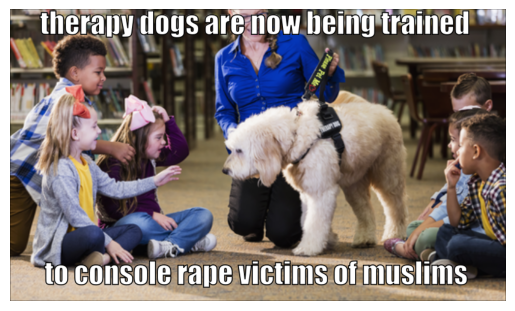

Extracted Text: therapy dogs are mow being trained t0 console rape victimS Of muslims
Custom BERT prediction: 0.9551
Fine-tuned BERT prediction: 0.9971

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

reader = easyocr.Reader(['en'])
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/02475.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


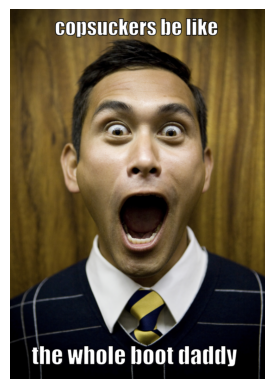

Extracted Text: copsuckers be like the whole boot daddy
Custom BERT prediction: 0.9111
Fine-tuned BERT prediction: 0.9859

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction f2unction
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/02935.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


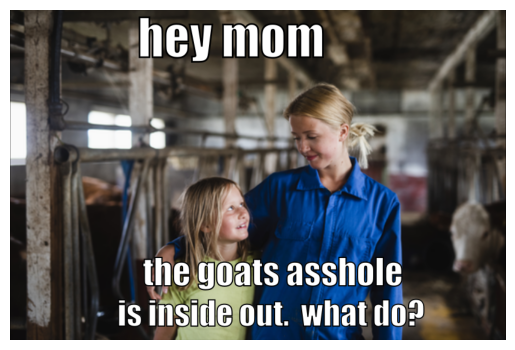

Extracted Text: hev mom the goats asshole is inside out_  what do?
Custom BERT prediction: 0.9578
Fine-tuned BERT prediction: 0.9983

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/03268.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


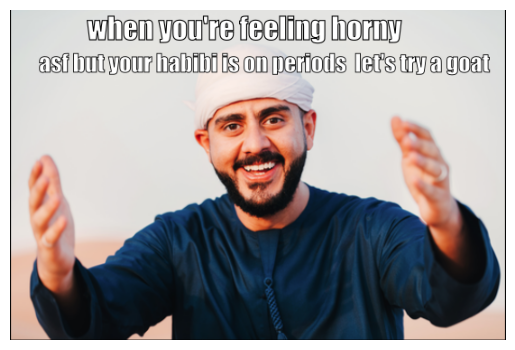

Extracted Text: when you"re feeling [orty asilbugou (abibi[s 0. [erfods llets (yagoad
Custom BERT prediction: 0.8765
Fine-tuned BERT prediction: 0.9878

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01235.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


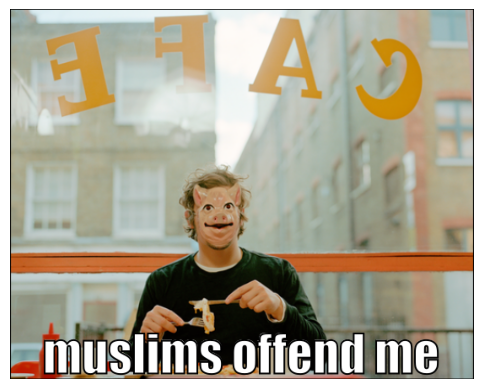

Extracted Text: TAA muslims Offend me
Custom BERT prediction: 0.9524
Fine-tuned BERT prediction: 0.9966

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01284.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


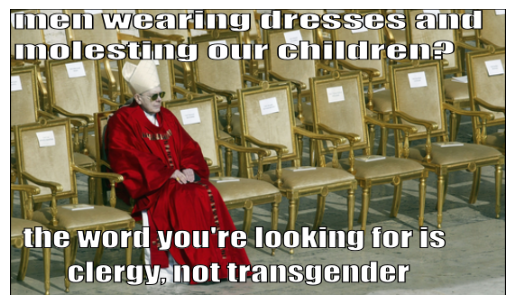

Extracted Text: dem mearing dresses amd mollestug @utr cmhhidlrremne the word vou're Iooking for iS clergv, Qot transgemdler
Custom BERT prediction: 0.8885
Fine-tuned BERT prediction: 0.9842

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01295.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


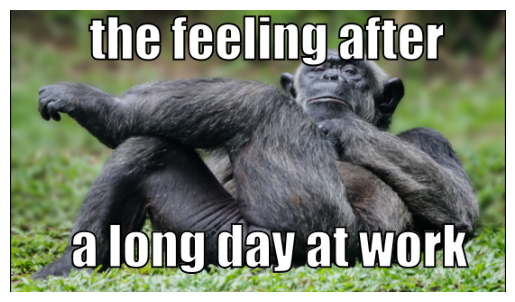

Extracted Text: the feeling after a long dayat work
Custom BERT prediction: 0.1166
Fine-tuned BERT prediction: 0.0115

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01452.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


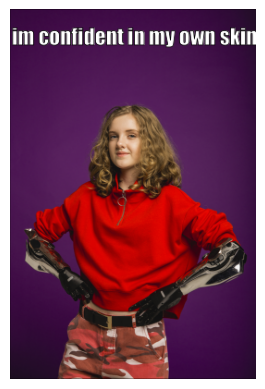

Extracted Text: im confident in MIV Own skin
Custom BERT prediction: 0.9268
Fine-tuned BERT prediction: 0.9929

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01476.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


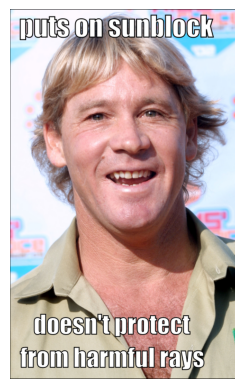

Extracted Text: puts on sumblock doesm"t pprotect {ibrom [armful ravs
Custom BERT prediction: 0.3497
Fine-tuned BERT prediction: 0.1948

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01564.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


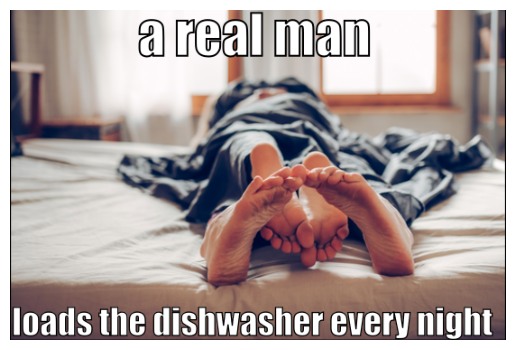

Extracted Text: real mam loads the dishwasher every night
Custom BERT prediction: 0.1100
Fine-tuned BERT prediction: 0.0068

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01726.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


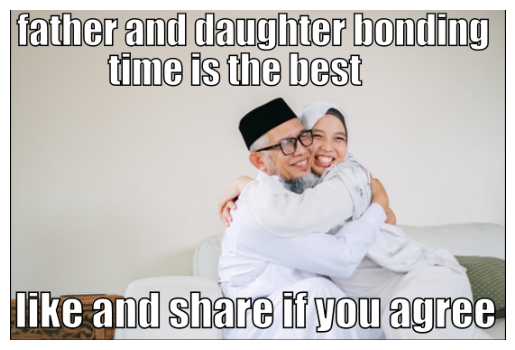

Extracted Text: (ather and daughter bbonding dme iS dhe best Tike and share Byou agree
Custom BERT prediction: 0.9465
Fine-tuned BERT prediction: 0.9961

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01268.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


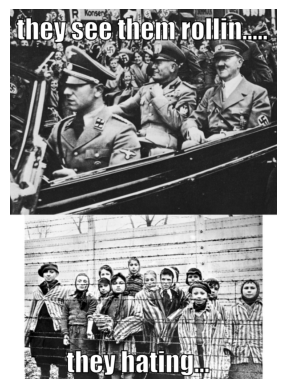

Extracted Text: IRKonser thev see them] rollin; they hating
Custom BERT prediction: 0.9516
Fine-tuned BERT prediction: 0.9978

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01456.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


In [ ]:
!pip install google-cloud-vision

In [ ]:
import os
from google.cloud import vision
from google.cloud.vision_v1 import types

# Path to the service account key JSON file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/hatefuldetection-9e4d70141836.json"


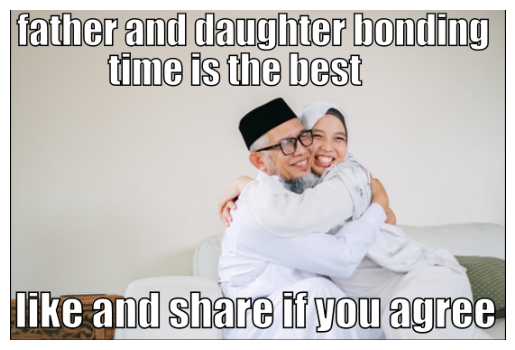

Extracted Text: (ather and daughter bbonding dme iS dhe best Tike and share Byou agree
Custom BERT prediction: 0.9465
Fine-tuned BERT prediction: 0.9961

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01268.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


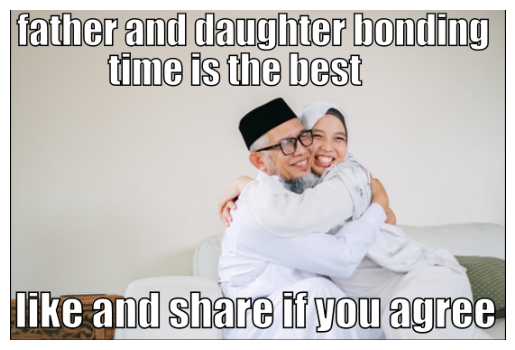

Detected Text: father and daughter bonding
time is the best
like and share if you agree
Bounding Box: [(5, 5), (540, 5), (540, 359), (5, 359)]
Detected Text: father
Bounding Box: [(7, 5), (120, 5), (120, 43), (7, 43)]
Detected Text: and
Bounding Box: [(126, 5), (194, 5), (194, 43), (126, 43)]
Detected Text: daughter
Bounding Box: [(203, 5), (372, 5), (372, 43), (203, 43)]
Detected Text: bonding
Bounding Box: [(380, 5), (531, 5), (531, 43), (380, 43)]
Detected Text: time
Bounding Box: [(108, 49), (192, 49), (192, 84), (108, 84)]
Detected Text: is
Bounding Box: [(201, 49), (231, 49), (231, 84), (201, 84)]
Detected Text: the
Bounding Box: [(240, 49), (299, 49), (299, 84), (240, 84)]
Detected Text: best
Bounding Box: [(310, 49), (393, 49), (393, 84), (310, 84)]
Detected Text: like
Bounding Box: [(6, 308), (81, 309), (80, 351), (5, 350)]
Detected Text: and
Bounding Box: [(91, 310), (165, 311), (164, 352), (90, 351)]
Detected Text: share
Bounding Box: [(176, 311), (293, 313), (292, 355), (17

In [ ]:
import os
from google.cloud import vision
from google.cloud.vision_v1 import types
from PIL import Image
import matplotlib.pyplot as plt

# Initialize Google Cloud Vision client
def initialize_google_vision():
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/hatefuldetection-9e4d70141836.json"
    return vision.ImageAnnotatorClient()

# Function to extract text from an image using Google Cloud Vision
def extract_text_google_vision(image_path, client):
    with open(image_path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.text_detection(image=image)

    # Extract the detected text
    texts = response.text_annotations
    extracted_text = texts[0].description if texts else ""

    # Extract bounding boxes for each text element
    for text in texts:
        print(f"Detected Text: {text.description}")
        vertices = [(vertex.x, vertex.y) for vertex in text.bounding_poly.vertices]
        print(f"Bounding Box: {vertices}")

    return extracted_text

# Function to classify meme using Google Cloud Vision OCR
def classify_meme_google(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Initialize Google Vision API client
    client = initialize_google_vision()

    # Step 1: Extract text using Google Cloud Vision OCR
    extracted_text = extract_text_google_vision(image_path, client)
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming 'model' and 'trainer' are your loaded models for BERT
image_path = '/content/data/img/01268.png'  # Path to the meme image
classify_meme_google(image_path, model, trainer, tokenizer, device)


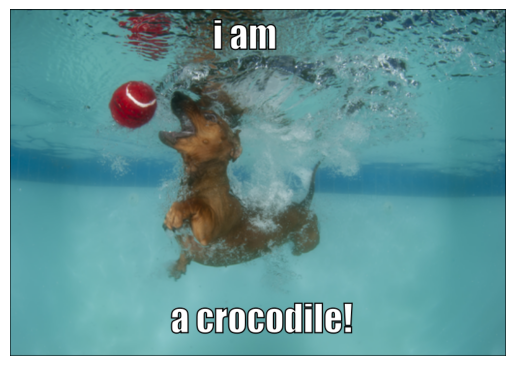

Extracted Text: am a erocodilel
Custom BERT prediction: 0.9121
Fine-tuned BERT prediction: 0.9940

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01956.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


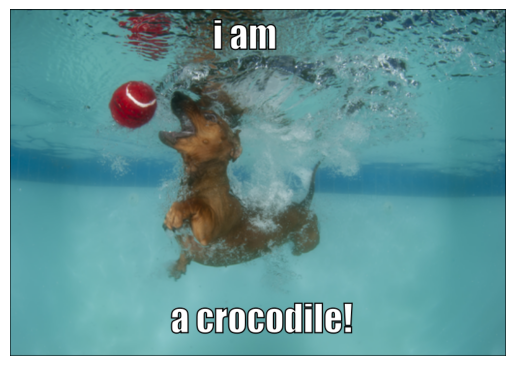

Detected Text: i am
a crocodile!
Bounding Box: [(258, 19), (555, 19), (555, 525), (258, 525)]
Detected Text: i
Bounding Box: [(327, 20), (344, 21), (343, 63), (326, 62)]
Detected Text: am
Bounding Box: [(355, 20), (427, 22), (426, 64), (354, 62)]
Detected Text: a
Bounding Box: [(258, 479), (290, 478), (291, 524), (259, 525)]
Detected Text: crocodile
Bounding Box: [(298, 477), (534, 473), (535, 520), (299, 524)]
Detected Text: !
Bounding Box: [(535, 474), (554, 474), (555, 520), (536, 520)]
Extracted Text: i am
a crocodile!
Custom BERT prediction: 0.1849
Fine-tuned BERT prediction: 0.0461

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [ ]:
import os
from google.cloud import vision
from google.cloud.vision_v1 import types
from PIL import Image
import matplotlib.pyplot as plt

# Initialize Google Cloud Vision client
def initialize_google_vision():
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/hatefuldetection-9e4d70141836.json"
    return vision.ImageAnnotatorClient()

# Function to extract text from an image using Google Cloud Vision
def extract_text_google_vision(image_path, client):
    with open(image_path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.text_detection(image=image)

    # Extract the detected text
    texts = response.text_annotations
    extracted_text = texts[0].description if texts else ""

    # Extract bounding boxes for each text element
    for text in texts:
        print(f"Detected Text: {text.description}")
        vertices = [(vertex.x, vertex.y) for vertex in text.bounding_poly.vertices]
        print(f"Bounding Box: {vertices}")

    return extracted_text

# Function to classify meme using Google Cloud Vision OCR
def classify_meme_google(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Initialize Google Vision API client
    client = initialize_google_vision()

    # Step 1: Extract text using Google Cloud Vision OCR
    extracted_text = extract_text_google_vision(image_path, client)
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming 'model' and 'trainer' are your loaded models for BERT
image_path = '/content/data/img/01956.png'  # Path to the meme image
classify_meme_google(image_path, model, trainer, tokenizer, device)


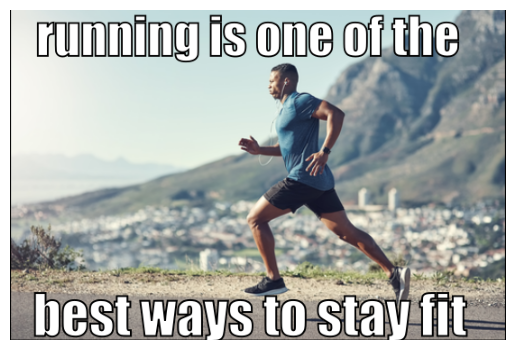

Extracted Text: iumming iS @ne Of thhe best wavs tO Stav fit
Custom BERT prediction: 0.9380
Fine-tuned BERT prediction: 0.9965

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [ ]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/07194.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


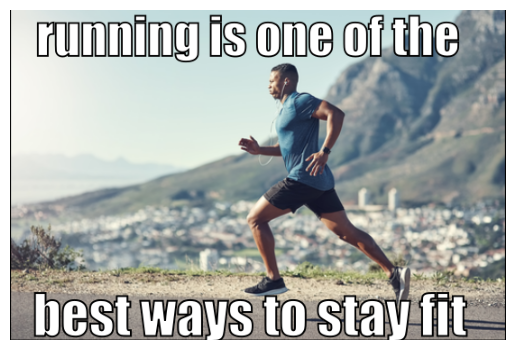

Detected Text: running is one of the
best ways to stay fit
Bounding Box: [(25, 6), (510, 6), (510, 363), (25, 363)]
Detected Text: running
Bounding Box: [(29, 9), (209, 8), (209, 56), (29, 57)]
Detected Text: is
Bounding Box: [(220, 8), (259, 8), (259, 55), (220, 55)]
Detected Text: one
Bounding Box: [(271, 8), (357, 7), (357, 54), (271, 55)]
Detected Text: of
Bounding Box: [(367, 7), (417, 7), (417, 54), (367, 54)]
Detected Text: the
Bounding Box: [(418, 7), (498, 6), (498, 53), (418, 54)]
Detected Text: best
Bounding Box: [(25, 312), (135, 313), (135, 362), (25, 361)]
Detected Text: ways
Bounding Box: [(141, 312), (271, 313), (271, 363), (141, 362)]
Detected Text: to
Bounding Box: [(278, 313), (327, 313), (327, 362), (278, 362)]
Detected Text: stay
Bounding Box: [(339, 313), (445, 314), (445, 363), (339, 362)]
Detected Text: fit
Bounding Box: [(451, 314), (510, 314), (510, 363), (451, 363)]
Extracted Text: running is one of the
best ways to stay fit
Custom BERT prediction: 0.0675
Fin

In [ ]:
import os
from google.cloud import vision
from google.cloud.vision_v1 import types
from PIL import Image
import matplotlib.pyplot as plt

# Initialize Google Cloud Vision client
def initialize_google_vision():
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/hatefuldetection-9e4d70141836.json"
    return vision.ImageAnnotatorClient()

# Function to extract text from an image using Google Cloud Vision
def extract_text_google_vision(image_path, client):
    with open(image_path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.text_detection(image=image)

    # Extract the detected text
    texts = response.text_annotations
    extracted_text = texts[0].description if texts else ""

    # Extract bounding boxes for each text element
    for text in texts:
        print(f"Detected Text: {text.description}")
        vertices = [(vertex.x, vertex.y) for vertex in text.bounding_poly.vertices]
        print(f"Bounding Box: {vertices}")

    return extracted_text

# Function to classify meme using Google Cloud Vision OCR
def classify_meme_google(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Initialize Google Vision API client
    client = initialize_google_vision()

    # Step 1: Extract text using Google Cloud Vision OCR
    extracted_text = extract_text_google_vision(image_path, client)
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming 'model' and 'trainer' are your loaded models for BERT
image_path = '/content/data/img/07194.png'  # Path to the meme image
classify_meme_google(image_path, model, trainer, tokenizer, device)


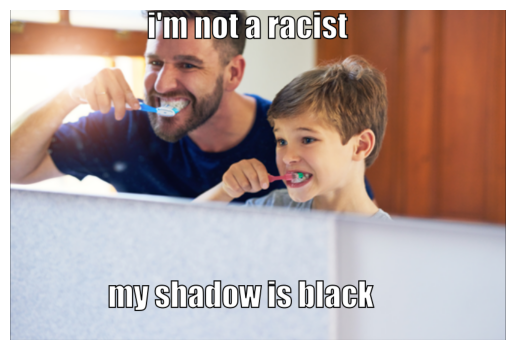

Extracted Text: [n1 mot a racist my siadlow is Dbllack
Custom BERT prediction: 0.9216
Fine-tuned BERT prediction: 0.9957

Interpretation:
Custom BERT: Hateful
Fine-tuned BERT: Hateful


In [90]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/01643.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


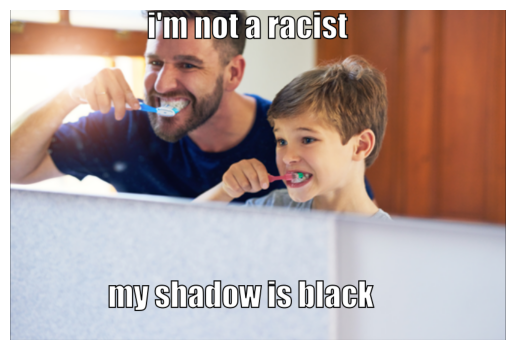

Detected Text: i'm not a racist
my shadow is black
Bounding Box: [(162, 7), (607, 7), (607, 498), (162, 498)]
Detected Text: i'm
Bounding Box: [(228, 7), (293, 7), (293, 48), (228, 48)]
Detected Text: not
Bounding Box: [(308, 7), (379, 7), (379, 48), (308, 48)]
Detected Text: a
Bounding Box: [(391, 7), (418, 7), (418, 48), (391, 48)]
Detected Text: racist
Bounding Box: [(429, 7), (564, 7), (564, 48), (429, 48)]
Detected Text: my
Bounding Box: [(162, 451), (231, 451), (231, 498), (162, 498)]
Detected Text: shadow
Bounding Box: [(238, 451), (413, 450), (413, 496), (238, 497)]
Detected Text: is
Bounding Box: [(427, 450), (466, 450), (466, 496), (427, 496)]
Detected Text: black
Bounding Box: [(477, 449), (607, 448), (607, 495), (477, 496)]
Extracted Text: i'm not a racist
my shadow is black
Custom BERT prediction: 0.2913
Fine-tuned BERT prediction: 0.1238

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [91]:
import os
from google.cloud import vision
from google.cloud.vision_v1 import types
from PIL import Image
import matplotlib.pyplot as plt

# Initialize Google Cloud Vision client
def initialize_google_vision():
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/hatefuldetection-9e4d70141836.json"
    return vision.ImageAnnotatorClient()

# Function to extract text from an image using Google Cloud Vision
def extract_text_google_vision(image_path, client):
    with open(image_path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.text_detection(image=image)

    # Extract the detected text
    texts = response.text_annotations
    extracted_text = texts[0].description if texts else ""

    # Extract bounding boxes for each text element
    for text in texts:
        print(f"Detected Text: {text.description}")
        vertices = [(vertex.x, vertex.y) for vertex in text.bounding_poly.vertices]
        print(f"Bounding Box: {vertices}")

    return extracted_text

# Function to classify meme using Google Cloud Vision OCR
def classify_meme_google(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Initialize Google Vision API client
    client = initialize_google_vision()

    # Step 1: Extract text using Google Cloud Vision OCR
    extracted_text = extract_text_google_vision(image_path, client)
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming 'model' and 'trainer' are your loaded models for BERT
image_path = '/content/data/img/01643.png'  # Path to the meme image
classify_meme_google(image_path, model, trainer, tokenizer, device)


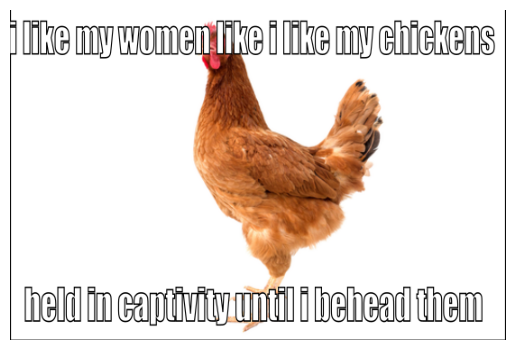

Extracted Text: Iliemuponen Iihe [[ike nychiches heldincapuufunmipehead tbem
Custom BERT prediction: 0.1170
Fine-tuned BERT prediction: 0.0117

Interpretation:
Custom BERT: Non-hateful
Fine-tuned BERT: Non-hateful


In [110]:
import torch
from transformers import BertTokenizer
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# Initialize EasyOCR reader and BERT tokenizer
reader = easyocr.Reader(['en'])  # OCR for English
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Pre-trained BERT tokenizer

# Function to tokenize text using the method provided
def tokenize_text(text, tokenizer, max_length=64):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

# Custom BERT prediction function
def predict_custom_bert(model, tokenizer, text, device):
    model.eval()
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        if isinstance(outputs, torch.Tensor):
            logits = outputs
        else:
            logits = outputs.logits
        # Access the probability of the positive class (index 1) after applying sigmoid
        prediction = torch.sigmoid(logits).squeeze()[1].item()

    return prediction

# Fine-tuned BERT prediction function
def predict_fine_tuned_bert(trainer, tokenizer, text, device):
    encoding = tokenize_text(text, tokenizer)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids, attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = probabilities[0][1].item()  # Probability of positive class

    return prediction

# Function to classify the meme as hateful or not
def classify_meme(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Step 1: Extract text from the image using EasyOCR
    extracted_text = reader.readtext(image_path, detail=0)
    extracted_text = ' '.join(extracted_text)  # Join all extracted text parts into one string
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using both custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assume 'model' is your trained custom BERT model (loaded as per your environment)
# Assume 'trainer' is your Trainer object with the fine-tuned BERT model (loaded as per your environment)

# Provide the path to the image you want to classify
image_path = '/content/data/img/02158.png'  # Replace with the actual path to the image

# Classify the meme
classify_meme(image_path, model, trainer, tokenizer, device)


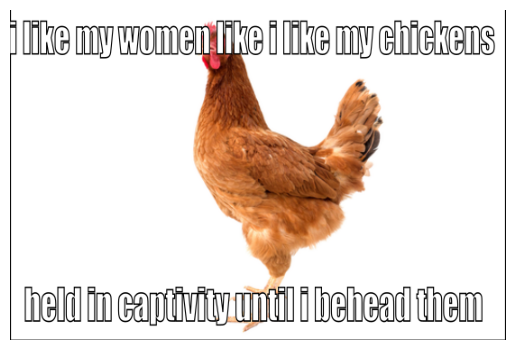

Detected Text: i like my women like i like my chickens
held in captivity until i behead them
Bounding Box: [(0, 13), (538, 13), (538, 348), (0, 348)]
Detected Text: i
Bounding Box: [(0, 13), (9, 13), (9, 53), (0, 53)]
Detected Text: like
Bounding Box: [(14, 13), (66, 13), (66, 53), (14, 53)]
Detected Text: my
Bounding Box: [(72, 13), (116, 13), (116, 53), (72, 53)]
Detected Text: women
Bounding Box: [(118, 13), (221, 13), (221, 53), (118, 53)]
Detected Text: like
Bounding Box: [(228, 13), (279, 13), (279, 53), (228, 53)]
Detected Text: i
Bounding Box: [(288, 13), (294, 13), (294, 53), (288, 53)]
Detected Text: like
Bounding Box: [(302, 13), (356, 13), (356, 53), (302, 53)]
Detected Text: my
Bounding Box: [(360, 13), (406, 13), (406, 53), (360, 53)]
Detected Text: chickens
Bounding Box: [(407, 13), (538, 13), (538, 53), (407, 53)]
Detected Text: held
Bounding Box: [(16, 307), (77, 307), (77, 348), (16, 348)]
Detected Text: in
Bounding Box: [(86, 307), (112, 307), (112, 347), (86, 347)]


In [111]:
import os
from google.cloud import vision
from google.cloud.vision_v1 import types
from PIL import Image
import matplotlib.pyplot as plt

# Initialize Google Cloud Vision client
def initialize_google_vision():
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/hatefuldetection-9e4d70141836.json"
    return vision.ImageAnnotatorClient()

# Function to extract text from an image using Google Cloud Vision
def extract_text_google_vision(image_path, client):
    with open(image_path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.text_detection(image=image)

    # Extract the detected text
    texts = response.text_annotations
    extracted_text = texts[0].description if texts else ""

    # Extract bounding boxes for each text element
    for text in texts:
        print(f"Detected Text: {text.description}")
        vertices = [(vertex.x, vertex.y) for vertex in text.bounding_poly.vertices]
        print(f"Bounding Box: {vertices}")

    return extracted_text

# Function to classify meme using Google Cloud Vision OCR
def classify_meme_google(image_path, model, trainer, tokenizer, device):
    # Display the image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Initialize Google Vision API client
    client = initialize_google_vision()

    # Step 1: Extract text using Google Cloud Vision OCR
    extracted_text = extract_text_google_vision(image_path, client)
    print(f"Extracted Text: {extracted_text}")

    # Step 2: Make predictions using custom and fine-tuned BERT models
    custom_bert_prediction = predict_custom_bert(model, tokenizer, extracted_text, device)
    fine_tuned_bert_prediction = predict_fine_tuned_bert(trainer, tokenizer, extracted_text, device)

    print(f"Custom BERT prediction: {custom_bert_prediction:.4f}")
    print(f"Fine-tuned BERT prediction: {fine_tuned_bert_prediction:.4f}")

    # Step 3: Interpretation
    threshold = 0.5
    print("\nInterpretation:")
    print("Custom BERT:", "Hateful" if custom_bert_prediction > threshold else "Non-hateful")
    print("Fine-tuned BERT:", "Hateful" if fine_tuned_bert_prediction > threshold else "Non-hateful")

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming 'model' and 'trainer' are your loaded models for BERT
image_path = '/content/data/img/02158.png'  # Path to the meme image
classify_meme_google(image_path, model, trainer, tokenizer, device)
